In [1]:
!pip install pandas numpy matplotlib seaborn plotly wordcloud textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.3 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.9 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.9 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.9 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.9 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.9 MB 1.5 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.9 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.9 MB 1.5 MB/s eta 0:00:05
   ------------ ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from textblob import TextBlob

from wordcloud import WordCloud

In [5]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

In [6]:
apps.head()
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [7]:
apps.shape
reviews.shape

(64295, 5)

In [8]:
apps.describe()

,Unnamed: 0,Rating,Reviews,Size
count,9659.000000,8196.000000,9.659000e+03,8432.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327
std,3102.362863,0.536625,1.831320e+06,21.827509
min,0.000000,1.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000
50%,5814.000000,4.300000,9.670000e+02,12.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000
max,10840.000000,5.000000,7.815831e+07,100.000000


In [9]:
apps.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [10]:
apps.dropna(inplace=True)

In [11]:
apps.duplicated().sum()

np.int64(0)

In [12]:
apps.drop_duplicates(inplace=True)

In [13]:
apps['Installs'] = apps['Installs'].str.replace(',', '')
apps['Installs'] = apps['Installs'].str.replace('+', '')
apps['Installs'] = apps['Installs'].astype(int)

In [14]:
apps['Price'] = apps['Price'].str.replace('$', '')
apps['Price'] = apps['Price'].astype(float)

In [15]:
apps['Rating'] = pd.to_numeric(
    apps['Rating'],
    errors='coerce'
)

In [16]:
apps['Category'].value_counts()

Category
FAMILY                 1511
GAME                    832
TOOLS                   625
PERSONALIZATION         274
LIFESTYLE               269
MEDICAL                 266
FINANCE                 258
PRODUCTIVITY            223
BUSINESS                222
SPORTS                  221
PHOTOGRAPHY             204
HEALTH_AND_FITNESS      191
COMMUNICATION           188
SOCIAL                  156
NEWS_AND_MAGAZINES      154
SHOPPING                146
BOOKS_AND_REFERENCE     141
TRAVEL_AND_LOCAL        141
DATING                  122
VIDEO_PLAYERS           112
MAPS_AND_NAVIGATION      94
EDUCATION                88
FOOD_AND_DRINK           72
ENTERTAINMENT            64
AUTO_AND_VEHICLES        63
LIBRARIES_AND_DEMO       60
ART_AND_DESIGN           58
HOUSE_AND_HOME           50
WEATHER                  50
COMICS                   47
PARENTING                44
EVENTS                   38
BEAUTY                   37
Name: count, dtype: int64

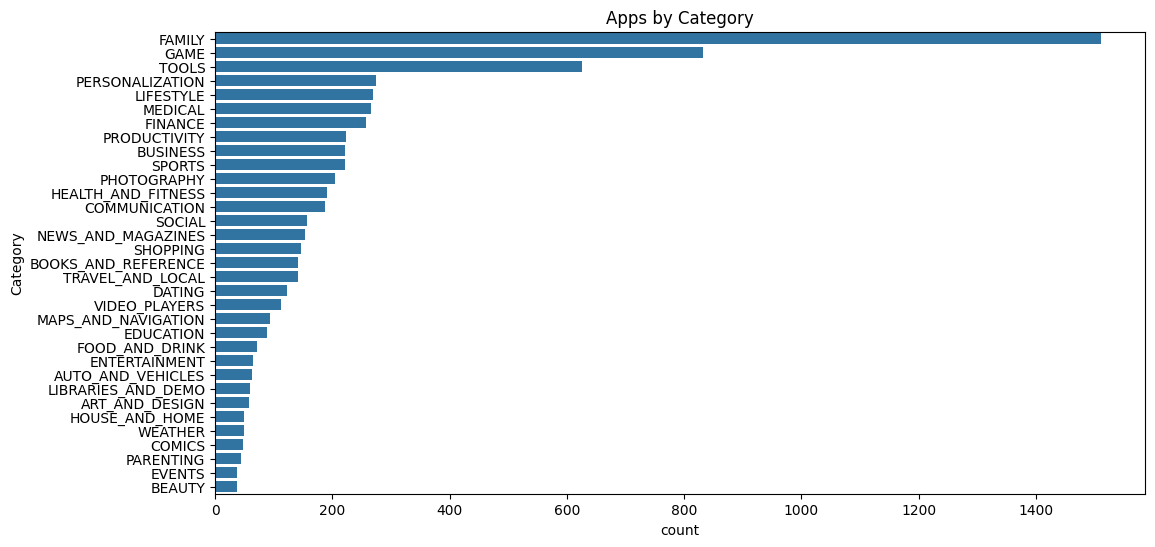

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Category',
    data=apps,
    order=apps['Category'].value_counts().index
)

plt.title("Apps by Category")
plt.savefig("figure1.png")
plt.show()

In [18]:
apps.groupby(
    'Category'
)['Rating'].mean().sort_values(
    ascending=False
)

Category
EVENTS                 4.478947
ART_AND_DESIGN         4.381034
EDUCATION              4.373864
PARENTING              4.347727
PERSONALIZATION        4.324453
BOOKS_AND_REFERENCE    4.322695
BEAUTY                 4.291892
SOCIAL                 4.257692
WEATHER                4.242000
GAME                   4.235697
SHOPPING               4.213014
LIBRARIES_AND_DEMO     4.205000
SPORTS                 4.200905
HEALTH_AND_FITNESS     4.191099
FAMILY                 4.179616
COMICS                 4.168085
MEDICAL                4.162406
ENTERTAINMENT          4.154687
AUTO_AND_VEHICLES      4.147619
NEWS_AND_MAGAZINES     4.143506
PRODUCTIVITY           4.132735
HOUSE_AND_HOME         4.128000
PHOTOGRAPHY            4.114216
FOOD_AND_DRINK         4.109722
FINANCE                4.104651
BUSINESS               4.096396
LIFESTYLE              4.089963
COMMUNICATION          4.076596
VIDEO_PLAYERS          4.021429
TRAVEL_AND_LOCAL       4.011348
MAPS_AND_NAVIGATION    4.008511

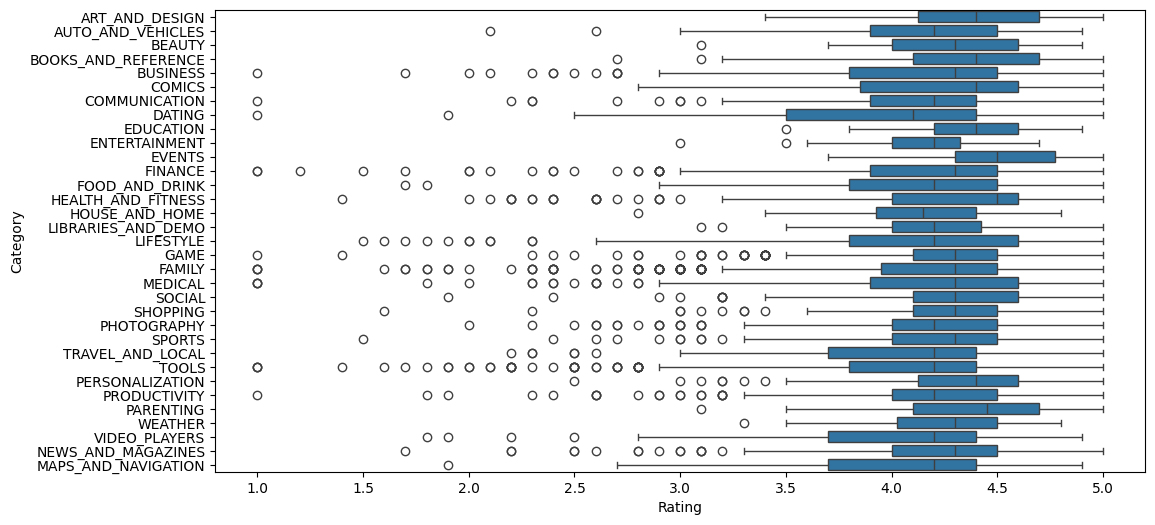

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Rating',
    y='Category',
    data=apps
)
plt.savefig("figure2.png")
plt.show()

In [20]:
apps[['App','Installs']].sort_values(
    by='Installs',
    ascending=False
).head(10)

,App,Installs
2977,Google News,1000000000
1356,Subway Surfers,1000000000
2527,SHAREit - Transfer & Share,500000000
1364,Pou,500000000
1363,Temple Run 2,500000000
2739,Dropbox,500000000
311,imo free video calls and chat,500000000
342,UC Browser - Fast Download Private & Secure,500000000
1357,Candy Crush Saga,500000000
4623,Samsung Health,500000000


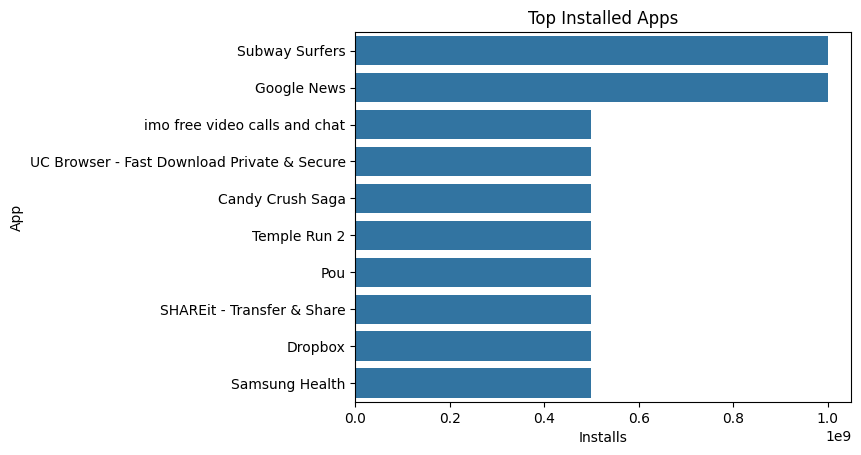

In [21]:
top_apps = apps.nlargest(
    10,
    'Installs'
)

sns.barplot(
    x='Installs',
    y='App',
    data=top_apps
)

plt.title("Top Installed Apps")
plt.savefig("figure3.png")
plt.show()

In [22]:
apps['Type'].value_counts()

Type
Free    6482
Paid     539
Name: count, dtype: int64

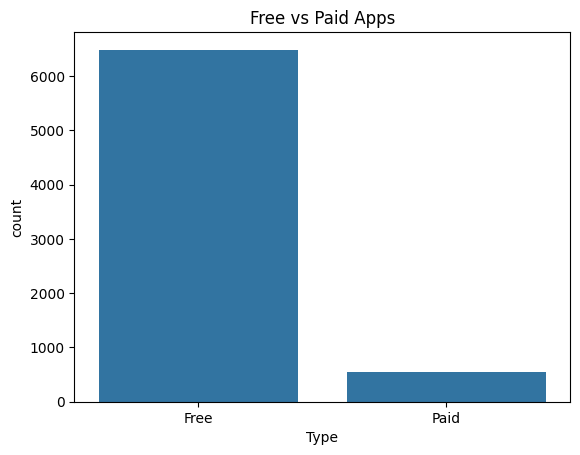

In [23]:
sns.countplot(
    x='Type',
    data=apps
)

plt.title(
    "Free vs Paid Apps"
)
plt.savefig("figure4.png")
plt.show()

In [24]:
apps['Price'].mean()

np.float64(1.1742216208517304)

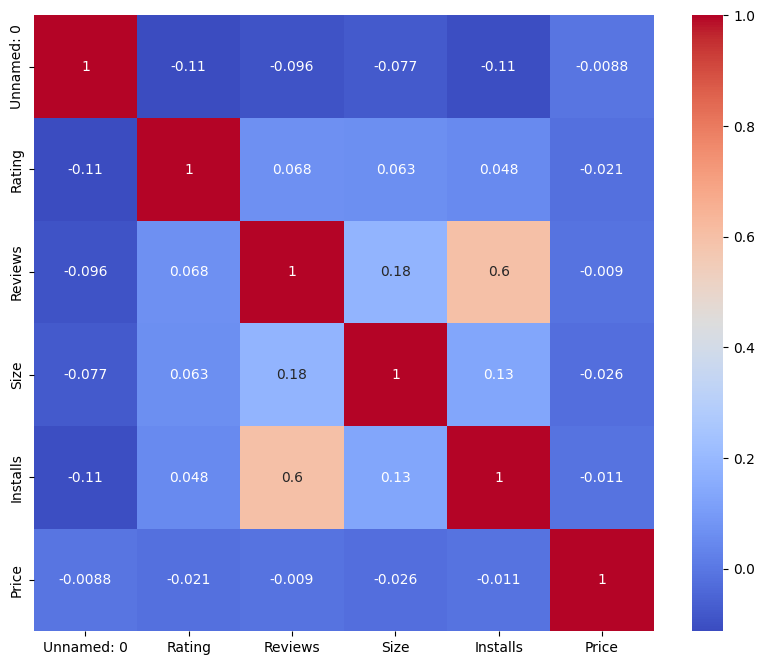

In [30]:
numeric_df = apps.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.savefig("figure5.png")
plt.show()

In [31]:
reviews.dropna(inplace=True)

In [32]:
reviews['Sentiment_Score'] = reviews[
    'Translated_Review'
].apply(
    lambda x:
    TextBlob(str(x)).sentiment.polarity
)

In [33]:
def sentiment(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

reviews['Sentiment_Type'] = reviews[
    'Sentiment_Score'
].apply(sentiment)

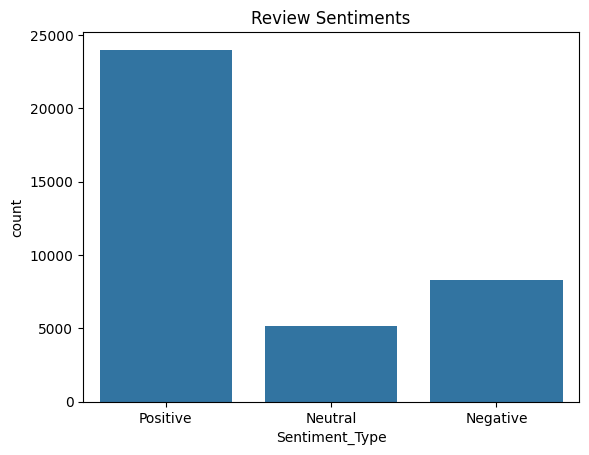

In [34]:
sns.countplot(
    x='Sentiment_Type',
    data=reviews
)

plt.title(
    "Review Sentiments"
)
plt.savefig("figure6.png")
plt.show()

In [35]:
text = " ".join(

reviews[
reviews['Sentiment_Type']=='Positive'
]['Translated_Review']

.astype(str)

)

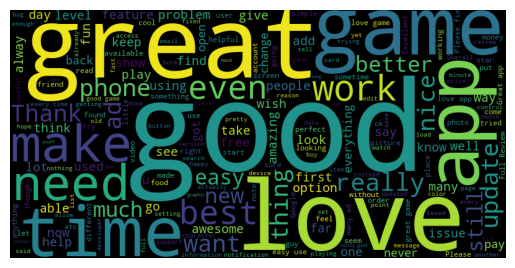

In [36]:
wordcloud = WordCloud(
    width=800,
    height=400
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")
plt.savefig("figure7.png")
plt.show()

In [37]:
fig = px.scatter(

apps,

x='Rating',

y='Installs',

color='Category',

hover_data=['App']

)

fig.show()